In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

print("Ready!")

Ready!


In [2]:
file = "2025-food-environment-atlas-data.xlsx"

restaurants = pd.read_excel(file, sheet_name="RESTAURANTS", header=1)
socio = pd.read_excel(file, sheet_name="SOCIOECONOMIC", header=1)

usda = restaurants[["FIPS", "State", "County", "FFRPTH20"]].merge(
    socio[["FIPS", "MEDHHINC21", "POVRATE21"]], on="FIPS"
)

print("USDA rows:", len(usda))

USDA rows: 3144


In [3]:
base = "https://data.cdc.gov/resource/swc5-untb.json?$limit=50000&measureid="

obesity = pd.DataFrame(requests.get(base + "OBESITY").json())
diabetes = pd.DataFrame(requests.get(base + "DIABETES").json())

def clean_cdc(data, col_name):
    data = data[data["data_value_type"] == "Crude prevalence"]
    data = data[data["locationid"].str.len() == 5]
    data = data[["locationid", "data_value"]].copy()
    data.columns = ["FIPS", col_name]
    data["FIPS"] = data["FIPS"].astype(int)
    data[col_name] = data[col_name].astype(float)
    return data

cdc = clean_cdc(obesity, "CDC_OBESITY").merge(
    clean_cdc(diabetes, "CDC_DIABETES"), on="FIPS"
)

print("CDC rows:", len(cdc))

CDC rows: 2957


In [4]:
df = usda.merge(cdc, on="FIPS")
df = df.replace([-8888, -9999], np.nan).dropna()

df.to_csv("clean_fastfood_health.csv", index=False)
print("Final shape:", df.shape)
print(df.head())

Final shape: (2489, 8)
   FIPS State   County  FFRPTH20  MEDHHINC21  POVRATE21  CDC_OBESITY  \
0  1001    AL  Autauga  0.801496     66444.0       10.7         39.8   
1  1003    AL  Baldwin  0.750152     65658.0       10.8         35.2   
2  1005    AL  Barbour  0.976046     38649.0       23.0         46.8   
3  1007    AL     Bibb  0.316227     48454.0       20.6         43.9   
4  1009    AL   Blount  0.414658     56894.0       12.0         36.1   

   CDC_DIABETES  
0          13.3  
1          13.4  
2          19.6  
3          16.2  
4          13.8  


In [5]:
print("Fast food vs obesity:  ", round(df["FFRPTH20"].corr(df["CDC_OBESITY"]), 3))
print("Poverty vs obesity:    ", round(df["POVRATE21"].corr(df["CDC_OBESITY"]), 3))
print("Income vs obesity:     ", round(df["MEDHHINC21"].corr(df["CDC_OBESITY"]), 3))
print("Fast food vs diabetes: ", round(df["FFRPTH20"].corr(df["CDC_DIABETES"]), 3))
print("Poverty vs diabetes:   ", round(df["POVRATE21"].corr(df["CDC_DIABETES"]), 3))

Fast food vs obesity:   -0.201
Poverty vs obesity:     0.496
Income vs obesity:      -0.597
Fast food vs diabetes:  -0.13
Poverty vs diabetes:    0.739


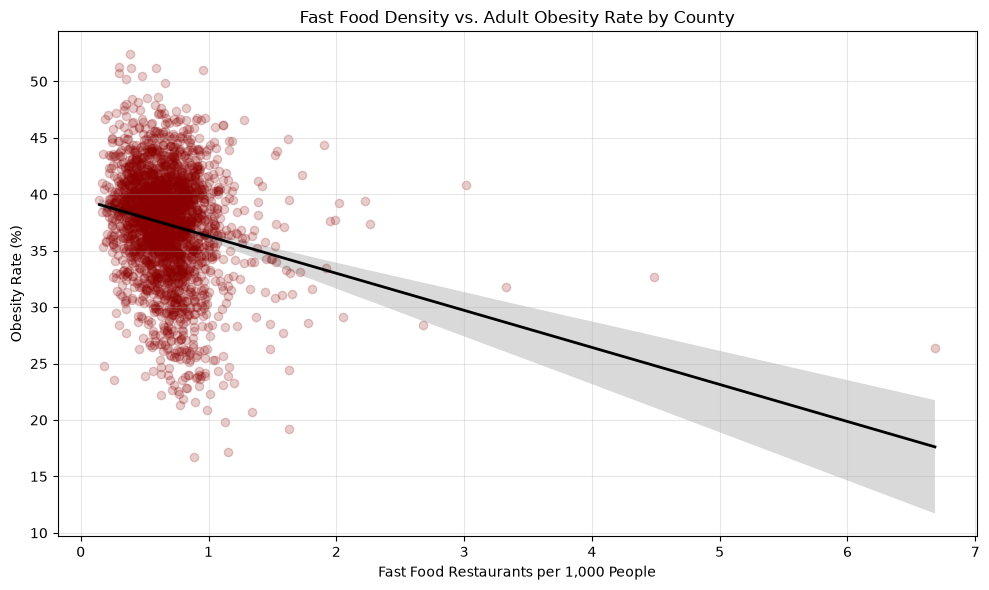

In [6]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="FFRPTH20", y="CDC_OBESITY",
            scatter_kws={"alpha": 0.2, "color": "darkred"},
            line_kws={"color": "black", "linewidth": 2})
plt.xlabel("Fast Food Restaurants per 1,000 People")
plt.ylabel("Obesity Rate (%)")
plt.title("Fast Food Density vs. Adult Obesity Rate by County")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("chart1.png", dpi=150)
plt.show()

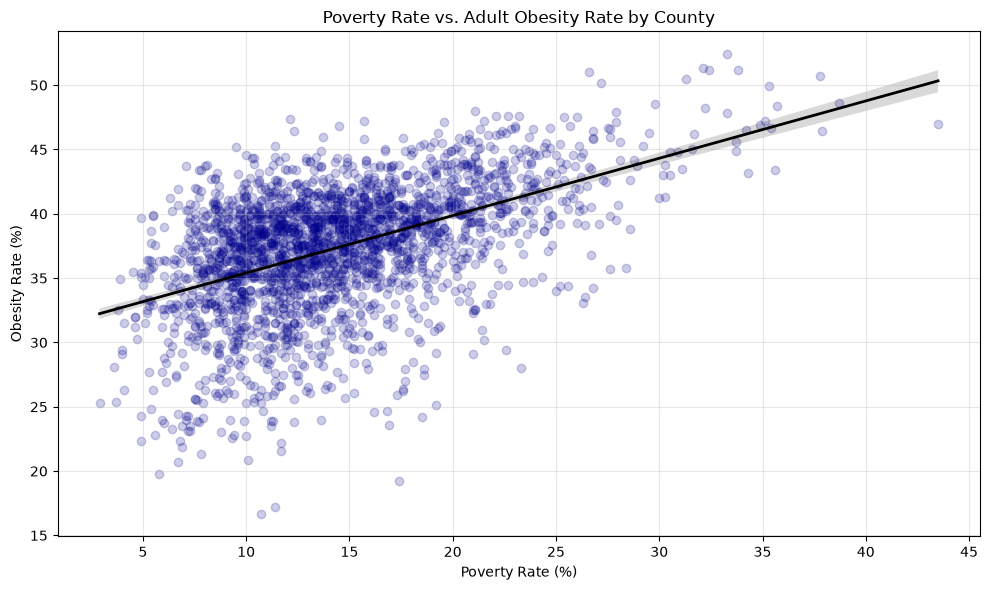

In [7]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="POVRATE21", y="CDC_OBESITY",
            scatter_kws={"alpha": 0.2, "color": "darkblue"},
            line_kws={"color": "black", "linewidth": 2})
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Obesity Rate (%)")
plt.title("Poverty Rate vs. Adult Obesity Rate by County")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("chart2.png", dpi=150)
plt.show()